**Step 1: Importing the required libraries**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from statistics import mean

**Step 2: Loading and cleaning the Data**

In [ ]:
# Loading the data into a Pandas DataFrame
data = pd.read_csv('kc_house_data.csv')

# Dropping the numerically non-sensical variables
dropColumns = ['id', 'date', 'zipcode']
data = data.drop(dropColumns, axis = 1)

# Separating the dependent and independent variables
y = data['price']
X = data.drop('price', axis = 1)

# Dividing the data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

Step 3: Building and evaluating the different models
a) Linear Regression:

In [ ]:
# Building and fitting the Linear Regression model
linearModel = LinearRegression()
linearModel.fit(X_train, y_train)

# Evaluating the Linear Regression model
print(linearModel.score(X_test, y_test))

0.6827704458266997


**b) Ridge(L2) Regression:**

In [ ]:
# List to maintain the different cross-validation scores
cross_val_scores_ridge = []

# List to maintain the different values of alpha
alpha = []

# Loop to compute the different values of cross-validation scores
for i in range(1, 9):
    ridgeModel = Ridge(alpha = i * 0.25)
    ridgeModel.fit(X_train, y_train)
    scores = cross_val_score(ridgeModel, X, y, cv = 10)
    avg_cross_val_score = mean(scores)*100
    cross_val_scores_ridge.append(avg_cross_val_score)
    alpha.append(i * 0.25)

# Loop to print the different values of cross-validation scores
for i in range(0, len(alpha)):
    print(str(alpha[i])+' : '+str(cross_val_scores_ridge[i]))

0.25 : 69.0911156663509
0.5 : 69.09129186188979
0.75 : 69.09144834696193
1.0 : 69.09158532099315
1.25 : 69.0917029847082
1.5 : 69.091801535573
1.75 : 69.09188117059462
2.0 : 69.09194208257827


From the above output, we can conclude that the best value of alpha for the data is 2.

In [ ]:
# Building and fitting the Ridge Regression model
ridgeModelChosen = Ridge(alpha = 2)
ridgeModelChosen.fit(X_train, y_train)

# Evaluating the Ridge Regression model
print(ridgeModelChosen.score(X_test, y_test))

0.6828597347845284


**c) Lasso(L1) Regression:**

In [ ]:
# List to maintain the cross-validation scores
cross_val_scores_lasso = []

# List to maintain the different values of Lambda
Lambda = []

# Loop to compute the cross-validation scores
for i in range(1, 9):
	lassoModel = Lasso(alpha = i * 0.25, tol = 0.0925)
	lassoModel.fit(X_train, y_train)
	scores = cross_val_score(lassoModel, X, y, cv = 10)
	avg_cross_val_score = mean(scores)*100
	cross_val_scores_lasso.append(avg_cross_val_score)
	Lambda.append(i * 0.25)

# Loop to print the different values of cross-validation scores
for i in range(0, len(alpha)):
	print(str(alpha[i])+' : '+str(cross_val_scores_lasso[i]))


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.301e+14, tolerance: 2.031e+14
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.920e+14, tolerance: 2.381e+14
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisa

0.25 : 69.08553871000579
0.5 : 69.08554408242492
0.75 : 69.08554942590989
1.0 : 69.0855547435584
1.25 : 69.08556003012117
1.5 : 69.08556529541958
1.75 : 69.08557052812642
2.0 : 69.08557574169015


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.963e+14, tolerance: 2.414e+14
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive


From the above output, we can conclude that the best value of lambda is 2.

In [ ]:
# Building and fitting the Lasso Regression Model
lassoModelChosen = Lasso(alpha = 2, tol = 0.0925)
lassoModelChosen.fit(X_train, y_train)

# Evaluating the Lasso Regression model
print(lassoModelChosen.score(X_test, y_test))

0.6827709358458753


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.302e+14, tolerance: 2.031e+14
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive


**Step 4: Comparing and Visualizing the results**

In [ ]:

# Building the two lists for visualization
models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
scores = [linearModel.score(X_test, y_test),
         ridgeModelChosen.score(X_test, y_test),
         lassoModelChosen.score(X_test, y_test)]

# Building the dictionary to compare the scores
mapping = {}
mapping['Linear Regression'] = linearModel.score(X_test, y_test)
mapping['Ridge Regression'] = ridgeModelChosen.score(X_test, y_test)
mapping['Lasso Regression'] = lassoModelChosen.score(X_test, y_test)

# Printing the scores for different models
for key, val in mapping.items():
    print(str(key)+' : '+str(val))

Linear Regression : 0.6827704458266997
Ridge Regression : 0.6828597347845284
Lasso Regression : 0.6827709358458753


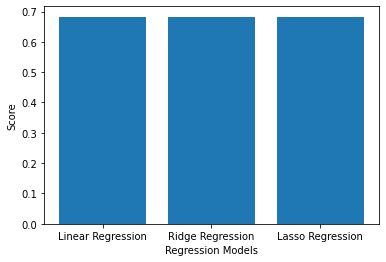

In [ ]:
# Plotting the scores
plt.bar(models, scores)
plt.xlabel('Regression Models')
plt.ylabel('Score')
plt.show()
